## 04 — Exploratory Data Analysis (EDA)
**Project:** SYST52461 — Healthcare Procurement Spend Analytics

This section loads all Gold tables, computes summary statistics and KPIs, and produces
8 visualizations to support the written report findings and dashboard.

| Plot | Dashboard Chart |
|---|---|
| Top 10 Vendors by Spend | Chart 1
| Monthly Spend Trend | Chart 2
| Spend by Category | Chart 3
| Spend by Subcategory (Stacked) | Chart 4
| Spend by Department | Chart 5
| PO Status Breakdown | Chart 6
| Vendor Concentration (Top 3%) | Chart 7
| Days to Pay vs. Payment Terms | Chart 8

**Run order:** This section requires `03_gold_aggregation.py` to load accordingly.

### Imports

In [0]:
import logging
import random
import re
from datetime import date, datetime, timedelta

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    DoubleType,
    IntegerType,
    StringType,
    StructField,
    StructType,
)

# Logging setup
# Configure global logging format and level for the module.
# This will ensure consistent timestamped logs across the pipeline.
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("procurement") # Named logger for this module

# Plot defaults

plt.rcParams["figure.dpi"]        = 110 # Higher DPI for sharper visuals
plt.rcParams["axes.spines.top"]   = False # Remove top border for cleaner look
plt.rcParams["axes.spines.right"] = False # Remove right border for cleaner look

# Catalog / schema constants
# These constants define the Unity Catalog / database schema used, throughout the
# procurement analytics pipeline.

CATALOG = "healthcare_procurement" 
SCHEMA  = "procurement_analytics"

log.info("Imports complete. Catalog=%s  Schema=%s", CATALOG, SCHEMA)

22:23:35  INFO  Imports complete. Catalog=healthcare_procurement  Schema=procurement_analytics


### Setup

In [0]:
# Using catalog and schema created previously

spark.sql(f"CREATE CATALOG IF NOT EXISTS {CATALOG}")
spark.sql(f"CREATE SCHEMA IF NOT EXISTS {CATALOG}.{SCHEMA}")
spark.sql(f"USE CATALOG {CATALOG}")
spark.sql(f"USE SCHEMA {SCHEMA}")

log.info("Using %s.%s", CATALOG, SCHEMA)

22:23:38  INFO  Using healthcare_procurement.procurement_analytics


### Helper Functions

In [0]:
# Reusable utilities

def write_table(df, table_name: str, mode: str = "overwrite") -> None:
    """Write a Spark DataFrame as a Delta table in the active schema."""
    full_name = f"{CATALOG}.{SCHEMA}.{table_name}"
    df.write.format("delta").mode(mode).saveAsTable(full_name)
    log.info("Written -> %s  (%d rows)", full_name, df.count())


def read_table(table_name: str):
    """Read a Delta table from the active schema and return a Spark DataFrame."""
    full_name = f"{CATALOG}.{SCHEMA}.{table_name}"
    df = spark.read.table(full_name)
    log.info("Loaded  <- %s  (%d rows)", full_name, df.count())
    return df


def null_report(df, label: str) -> None:
    """Print a count of null values for every column in the DataFrame."""
    null_counts = df.select([
        F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns
    ])
    print(f"\nNull report -- {label}")
    null_counts.show()


log.info("Helper functions defined.")

22:23:38  INFO  Helper functions defined.


### Load Gold Tables

In [0]:
# Load Gold tables and convert to Pandas for plotting.
# Gold tables are aggregated and small enough to fit in driver memory.

vendor_df   = read_table("gold_spend_by_vendor").toPandas()
dept_df     = read_table("gold_spend_by_department").toPandas()
monthly_df  = read_table("gold_monthly_trend").toPandas()
payment_df  = read_table("gold_payment_cycle").toPandas()
taxonomy_df = read_table("gold_spend_by_taxonomy").toPandas()
po_status_df = read_table("silver_purchase_orders").toPandas()

log.info("Gold tables loaded — vendor: %d, dept: %d, monthly: %d, payment: %d, taxonomy: %d",
         len(vendor_df), len(dept_df), len(monthly_df), len(payment_df), len(taxonomy_df))

22:23:39  INFO  Loaded  <- healthcare_procurement.procurement_analytics.gold_spend_by_vendor  (20 rows)
22:23:40  INFO  Loaded  <- healthcare_procurement.procurement_analytics.gold_spend_by_department  (20 rows)
22:23:41  INFO  Loaded  <- healthcare_procurement.procurement_analytics.gold_monthly_trend  (24 rows)
22:23:42  INFO  Loaded  <- healthcare_procurement.procurement_analytics.gold_payment_cycle  (321 rows)
22:23:43  INFO  Loaded  <- healthcare_procurement.procurement_analytics.gold_spend_by_taxonomy  (10 rows)
22:23:44  INFO  Loaded  <- healthcare_procurement.procurement_analytics.silver_purchase_orders  (481 rows)
22:23:44  INFO  Gold tables loaded — vendor: 20, dept: 20, monthly: 24, payment: 321, taxonomy: 10


### Summary Statistics

In [0]:
# Summary Statistics

print("== gold_spend_by_vendor ==")
print(vendor_df[["total_pos", "total_spend", "avg_po_value"]].describe().round(2))

print("\n== gold_monthly_trend ==")
print(monthly_df[["total_pos", "total_spend"]].describe().round(2))

print("\n== gold_payment_cycle ==")
print(payment_df[["days_to_pay", "terms_days", "is_late"]].describe().round(2))
print(f"\n  Late payment rate: {payment_df['is_late'].mean()*100:.1f}%")

== gold_spend_by_vendor ==
       total_pos  total_spend  avg_po_value
count      20.00        20.00         20.00
mean       17.00    422914.98      24915.36
std         2.88     84766.92       3080.32
min        11.00    227290.57      16901.69
25%        15.75    382689.12      23626.14
50%        17.50    429131.78      25523.03
75%        18.25    477374.60      26687.28
max        23.00    610086.12      30250.07

== gold_monthly_trend ==
       total_pos  total_spend
count      24.00        24.00
mean       14.17    352429.15
std         3.55     97569.13
min         5.00    152955.91
25%        12.00    292527.69
50%        14.00    358439.92
75%        16.00    411353.15
max        22.00    530003.22

== gold_payment_cycle ==
       days_to_pay  terms_days  is_late
count       321.00      321.00   321.00
mean         45.37       41.96     0.54
std          18.07       12.99     0.50
min          15.00       30.00     0.00
25%          30.00       30.00     0.00
50%          44

### KPI Summary

In [0]:
# KPI Summary

total_spend  = vendor_df["total_spend"].sum()
total_pos    = vendor_df["total_pos"].sum()
top3_spend   = vendor_df.head(3)["total_spend"].sum()
top3_pct     = top3_spend / total_spend * 100 if total_spend else 0
avg_dtp      = payment_df["days_to_pay"].mean()
late_pct     = payment_df["is_late"].mean() * 100

kpis = {
    "Total Approved Spend":      f"${total_spend:,.2f}",
    "Total Approved POs":        f"{int(total_pos):,}",
    "Top 3 Vendor Spend Share":  f"{top3_pct:.1f}%",
    "Avg Days to Pay":           f"{avg_dtp:.1f} days",
    "Late Payment Rate":         f"{late_pct:.1f}%",
    "Unique Vendors":            f"{vendor_df['vendor_id'].nunique()}",
    "Unique Departments":        f"{dept_df['department_id'].nunique()}",
}


print("   PROCUREMENT KEY PERFORMANCE INDICATORS","\n")

for k, v in kpis.items():
    print(f"  {k:<32} {v}")


   PROCUREMENT KEY PERFORMANCE INDICATORS 

  Total Approved Spend             $8,458,299.54
  Total Approved POs               340
  Top 3 Vendor Spend Share         19.4%
  Avg Days to Pay                  45.4 days
  Late Payment Rate                53.9%
  Unique Vendors                   20
  Unique Departments               20


### Plot 1 — Top 10 Vendors by Spend
> Dashboard Chart 1

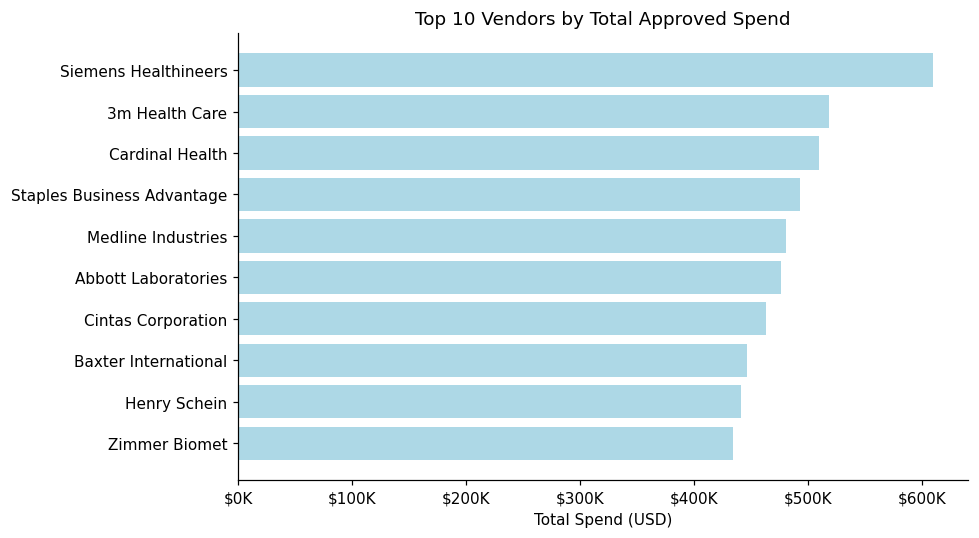

In [0]:
top10 = vendor_df.head(10).sort_values("total_spend") 
# Sorting ensures the bar chart displays vendors in ascending spend order.

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10["vendor_name"], top10["total_spend"], color="lightblue")
# Horizontal bars make long vendor names easier to read.

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}K"))
# FuncFormatter will let us apply a custom formatting function to each tick.

ax.set_title("Top 10 Vendors by Total Approved Spend")
ax.set_xlabel("Total Spend (USD)")
plt.tight_layout()
plt.show()

### Plot 2 — Monthly Spend Trend
> Dashboard Chart 2

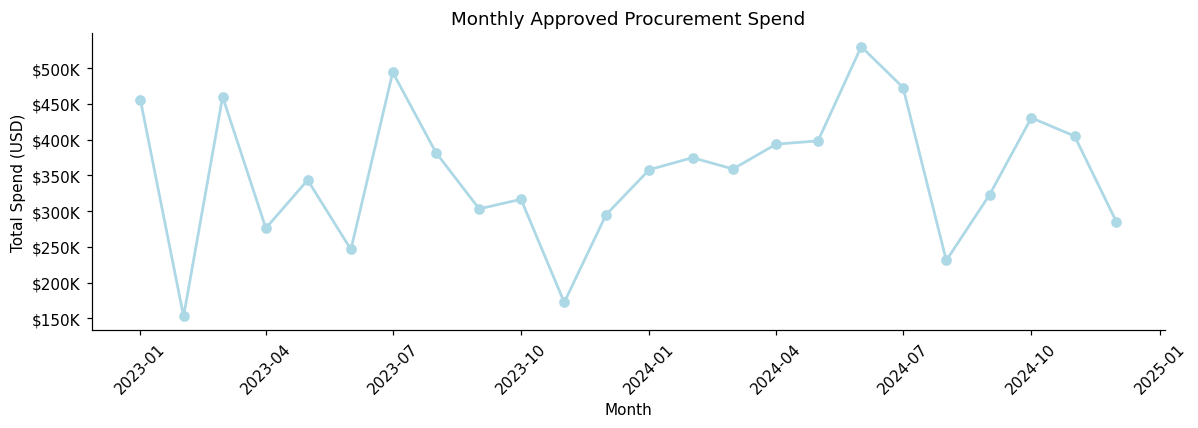

In [0]:
monthly_df["date"] = pd.to_datetime(monthly_df["year_month"] + "-01")

monthly_sorted = monthly_df.sort_values("date")
# Sort the data chronologically so the line plot moves left → right in time.

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly_sorted["date"], monthly_sorted["total_spend"],
        marker="o", linewidth=1.8, color="lightblue")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}K"))
ax.set_title("Monthly Approved Procurement Spend")
ax.set_xlabel("Month")
ax.set_ylabel("Total Spend (USD)")
plt.xticks(rotation=45) # Rotate x-axis labels so month names don't overlap.
plt.tight_layout()
plt.show()

### Plot 3 — Spend by Category
> Dashboard Chart 3

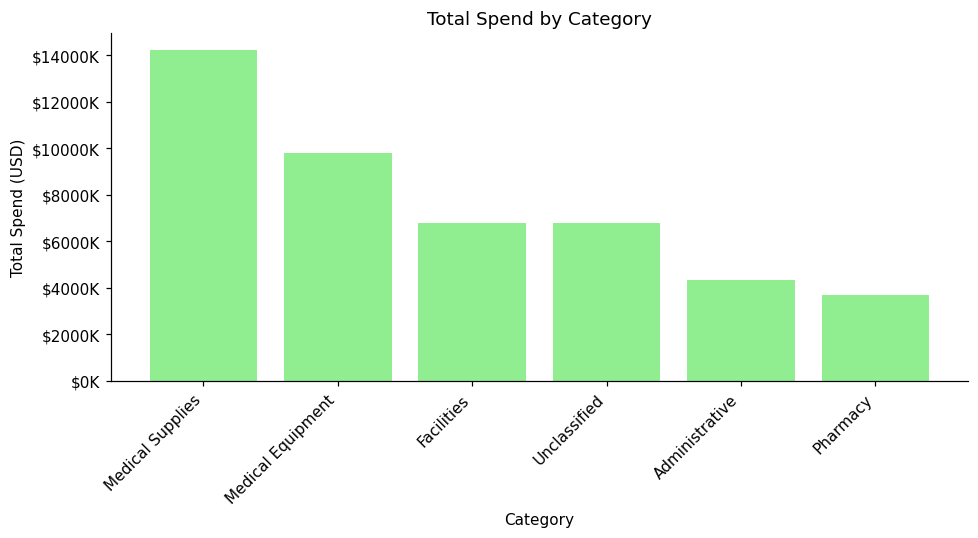

In [0]:
# We will group the taxonomy data by category and sum the total spend for each one.
# This produces a single spend value per category.

cat_summary = (
    taxonomy_df.groupby("category")["total_spend"]
    .sum().sort_values(ascending=False).reset_index() 
)
# Sort categories from highest to lowest spend

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(cat_summary["category"], cat_summary["total_spend"], color="lightgreen")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}K"))
ax.set_title("Total Spend by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Total Spend (USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Plot 4 — Spend by Subcategory (Stacked Bar)
> Dashboard Chart 4

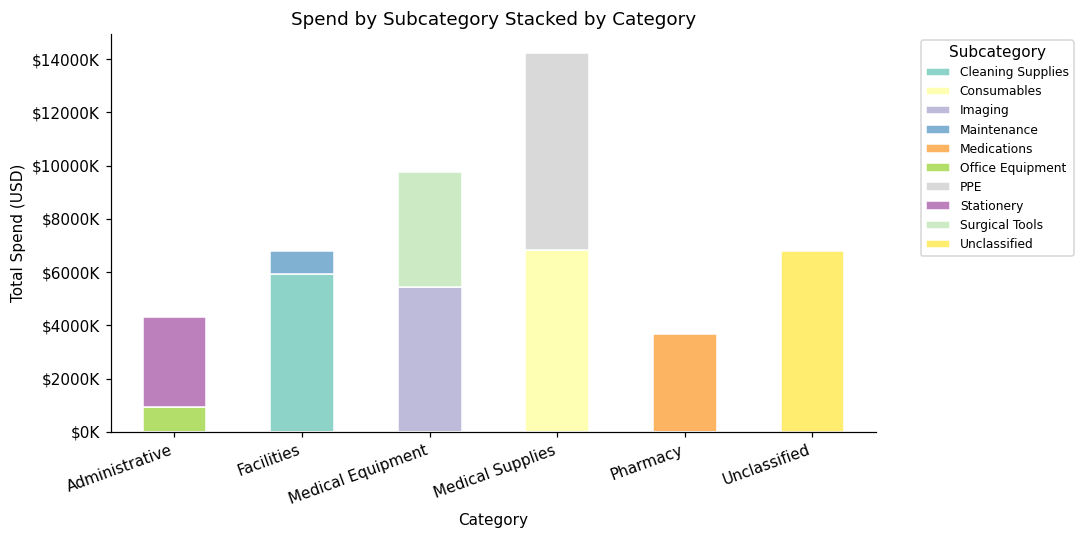

In [0]:
# Create a pivot table where:
# - Rows = categories
# - Columns = subcategories
# - Values = summed spend for each (category, subcategory) pair

subcat_pivot = (
    taxonomy_df.groupby(["category", "subcategory"])["total_spend"]
    .sum().unstack(fill_value=0)
)
# structure ideal for stacked bar charts. fill_value=0 ensures missing
# combinations appear as zeros instead of NaN.


# Plot the pivot table as a stacked bar chart.
# Each bar represents a category, and each colored segment represents a subcategory.
subcat_pivot.plot(kind="bar", stacked=True, figsize=(10, 5),
                  colormap="Set3", edgecolor="white")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}K"))
plt.title("Spend by Subcategory Stacked by Category")
plt.xlabel("Category")
plt.ylabel("Total Spend (USD)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Subcategory", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### Plot 5 — Spend by Department
> Dashboard Chart 5

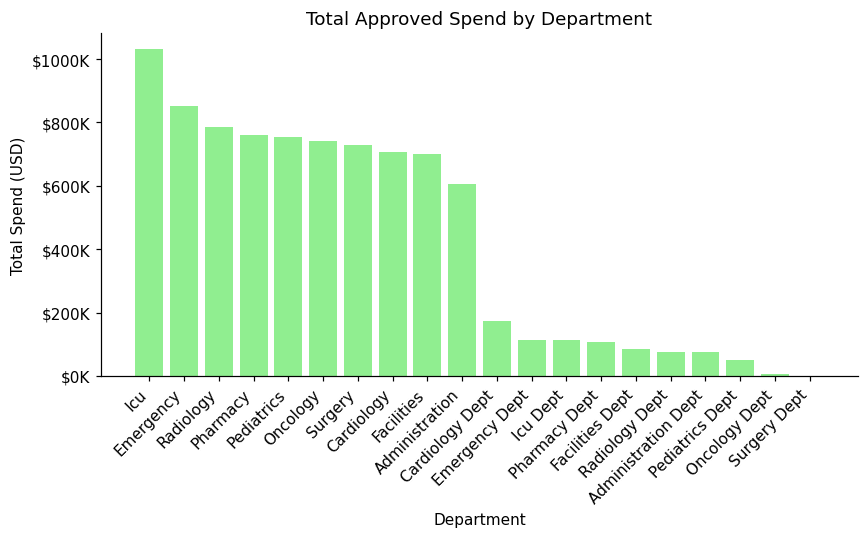

In [0]:
# Sort departments by total spend in descending order so the highest‑spend departments appear first.
dept_sorted = dept_df.sort_values("total_spend", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(dept_sorted["department_id"], dept_sorted["total_spend"], color="LightGreen")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}K"))
ax.set_title("Total Approved Spend by Department")
ax.set_xlabel("Department")
ax.set_ylabel("Total Spend (USD)")
plt.xticks(rotation=45, ha="right")
# Rotate department labels so they remain readable, especially if IDs are long.

plt.tight_layout()
plt.show()

### Plot 6 — PO Status Breakdown
> Dashboard Chart 6

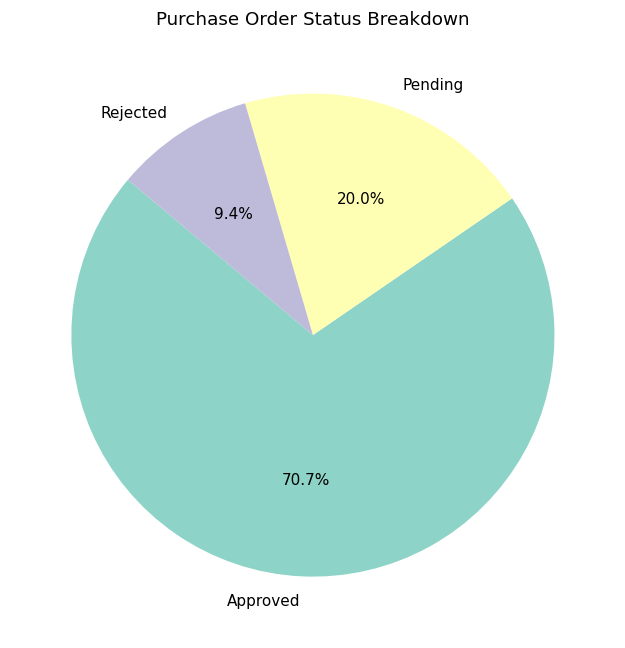

In [0]:
# Count how many purchase orders fall into each status category.
# value_counts() returns a Series indexed by status with counts as values.
status_counts = po_status_df["status"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(status_counts, labels=status_counts.index, autopct="%1.1f%%",
       startangle=140, colors=plt.cm.Set3.colors)
ax.set_title("Purchase Order Status Breakdown")
plt.tight_layout()
plt.show()

### Plot 7 — Vendor Concentration (Top 3%)
> Dashboard Chart 7

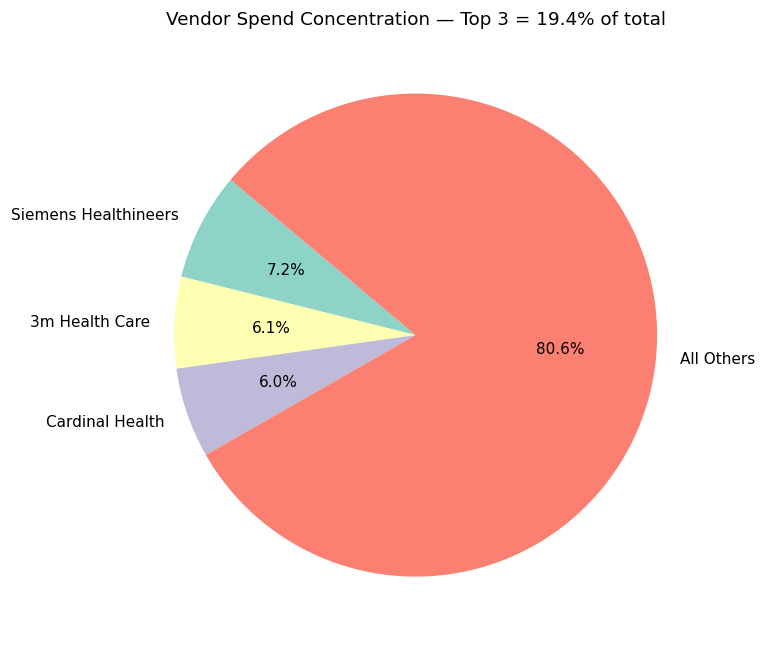

In [0]:
total_spend  = vendor_df["total_spend"].sum() # Calculate total spend across all vendors

top3_spend   = vendor_df.head(3)["total_spend"].sum()
# Sum of the top 3 vendors (assuming vendor_df is already sorted by spend)

others_spend = total_spend - top3_spend # Spend from all remaining vendors


labels = list(vendor_df.head(3)["vendor_name"]) + ["All Others"]
values = list(vendor_df.head(3)["total_spend"]) + [others_spend]

fig, ax = plt.subplots(figsize=(7, 6))
ax.pie(values, labels=labels, autopct="%1.1f%%",
       startangle=140, colors=plt.cm.Set3.colors)
ax.set_title(f"Vendor Spend Concentration — Top 3 = {top3_spend/total_spend*100:.1f}% of total")
plt.tight_layout()
plt.show()

### Plot 8 — Days to Pay vs. Payment Terms
> Dashboard Chart 8

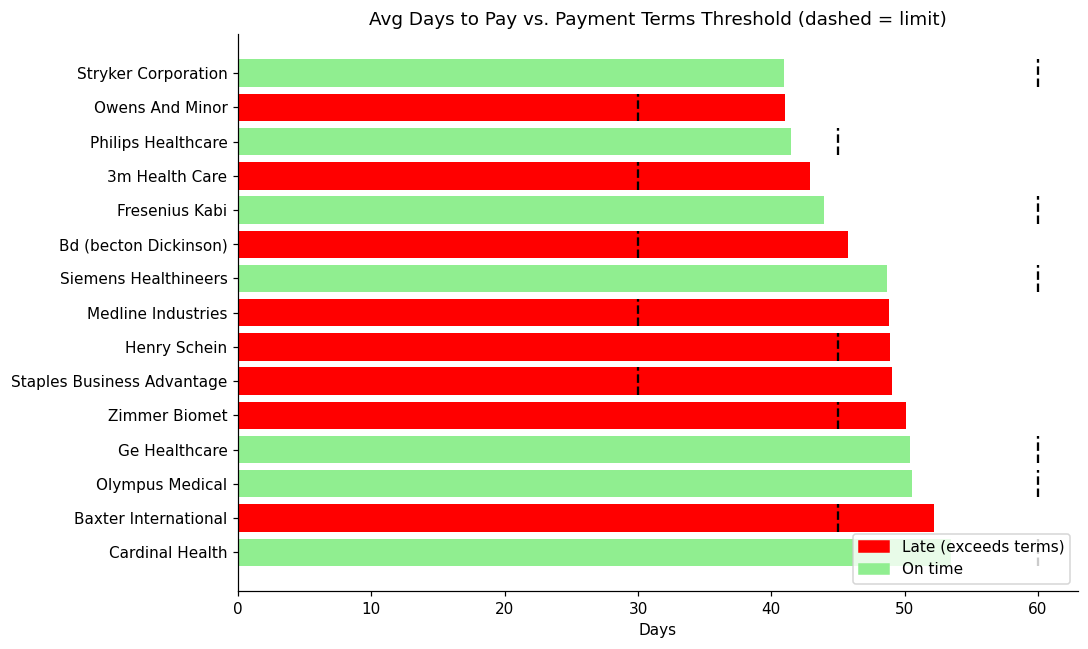

In [0]:
# Compute the average days to pay for each vendor + their payment terms
avg_days = (
    payment_df.groupby(["vendor_name", "payment_terms", "terms_days"])["days_to_pay"]
    .mean().reset_index() 
    # average days to pay per vendor, and convert groupby object back to DataFrame
    .rename(columns={"days_to_pay": "avg_days_to_pay"})
    .sort_values("avg_days_to_pay", ascending=False) # sort by slowest payers
    .head(15)
)

# Color vendors red if they exceed their payment terms, green if within terms
colors = ["red" if row["avg_days_to_pay"] > row["terms_days"] else "lightgreen"
          for _, row in avg_days.iterrows()]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(avg_days["vendor_name"], avg_days["avg_days_to_pay"], color=colors)
for i, (_, row) in enumerate(avg_days.iterrows()):
    ax.plot([row["terms_days"], row["terms_days"]], [i - 0.4, i + 0.4],
            color="black", linewidth=1.5, linestyle="--") 
    # Draw dashed vertical line for each vendor's payment terms threshold
ax.set_title("Avg Days to Pay vs. Payment Terms Threshold (dashed = limit)")
ax.set_xlabel("Days")
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color="Red",    label="Late (exceeds terms)"),
    plt.Rectangle((0,0),1,1, color="lightgreen", label="On time"),
], loc="lower right")
plt.tight_layout()
plt.show()

### EDA Insight Summary
> Use this to write the EDA Findings section of the report

In [0]:

print("EDA INSIGHT SUMMARY — for written report")

# INSIGHT 1: Vendor Spend Concentration
# Top vendor (assuming vendor_df is sorted by total_spend descending)
top1     = vendor_df.iloc[0]

# % of total spend accounted for by the top 3 vendors
top3_pct = vendor_df.head(3)["total_spend"].sum() / vendor_df["total_spend"].sum() * 100
print(f"\n  INSIGHT 1 — Vendor Concentration")
print(f"  Top vendor: '{top1['vendor_name']}' — ${top1['total_spend']:,.0f}")
print(f"  Top 3 vendors = {top3_pct:.1f}% of total approved spend.")


# INSIGHT 2: Payment Compliance
# % of POs that were paid late
late_pct      = payment_df["is_late"].mean() * 100

# Average days to pay among late POs only
avg_late_days = payment_df[payment_df["is_late"] == 1]["days_to_pay"].mean()
print(f"\n  INSIGHT 2 — Payment Compliance")
print(f"  {late_pct:.1f}% of approved POs were paid late.")
print(f"  Avg days to pay (late POs): {avg_late_days:.1f} days.")

# INSIGHT 3: Spend by Category
# Identify the category with the highest total spend
top_cat       = taxonomy_df.groupby("category")["total_spend"].sum().idxmax()

# Total spend for that category
top_cat_spend = taxonomy_df.groupby("category")["total_spend"].sum().max()
print(f"\n  INSIGHT 3 — Top Spend Category")
print(f"  '{top_cat}' — ${top_cat_spend:,.0f}")


EDA INSIGHT SUMMARY — for written report

  INSIGHT 1 — Vendor Concentration
  Top vendor: 'Siemens Healthineers' — $610,086
  Top 3 vendors = 19.4% of total approved spend.

  INSIGHT 2 — Payment Compliance
  53.9% of approved POs were paid late.
  Avg days to pay (late POs): 57.5 days.

  INSIGHT 3 — Top Spend Category
  'Medical Supplies' — $14,226,604
